In [31]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

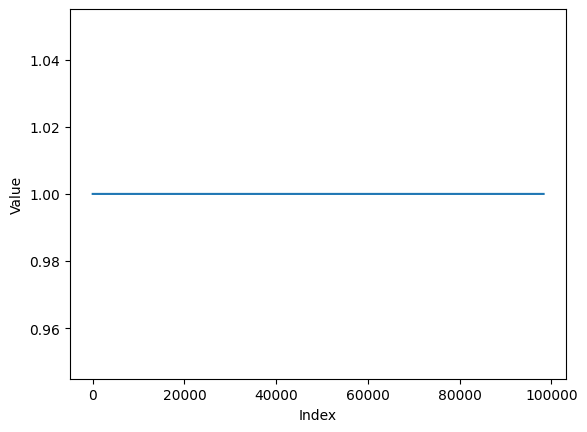

In [32]:
df = pd.read_csv('fc_0.csv')
x  = df['frame_count']
x  = np.diff(x)
plt.plot(x)
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

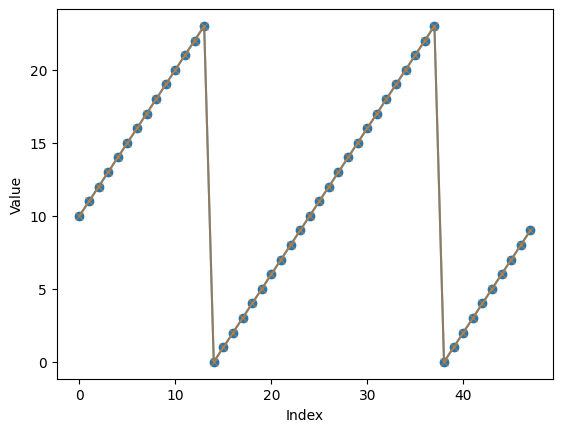

In [33]:
t0 = 0
t1 = t0+24*2
df = pd.read_csv('fc_0.csv')
x  = df['value'].to_numpy()
of = x[0]

def op():
    return (np.arange(len(x))+of) % 24

y  = op()
q  = np.arange(len(x))
x  = x[t0:t1]
y  = y[t0:t1]
q  = q[t0:t1]

plt.plot(q, x, marker='o')
plt.plot(q, y, marker='x',alpha=0.5)
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

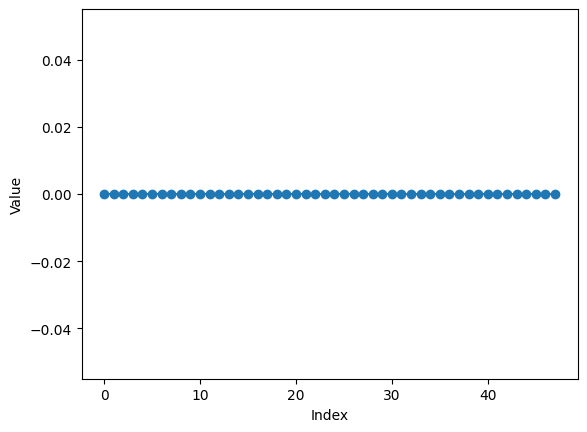

In [34]:
df = pd.read_csv('fc_0.csv')
x  = df['value'].to_numpy()
y  = op()

N    = 24
diff = (x - y) % N
dist = np.minimum(diff, N - diff)

q  = np.arange(len(x))
z  = dist[t0:t1]
q  = q[t0:t1]
plt.plot(q, z, marker='o')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

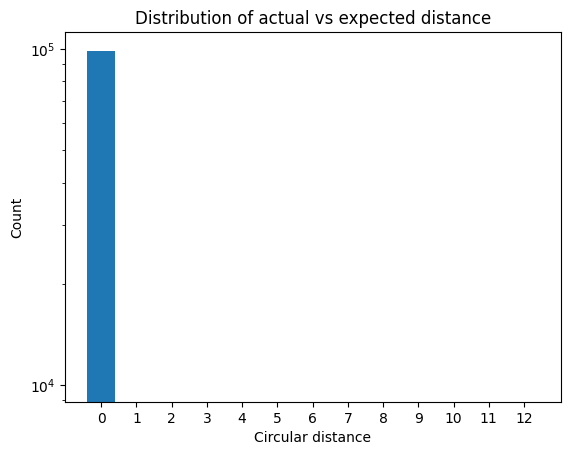

In [35]:
df = pd.read_csv('fc_0.csv')
x  = df['value'].to_numpy()
y  = op()

N    = 24
diff = (x - y) % N
dist = np.minimum(diff, N - diff)

# Distribution: counts of each distance
counts = np.bincount(dist.astype(int), minlength=N//2 + 1)

dist_distribution = pd.DataFrame({
    "distance": np.arange(N//2 + 1),
    "count": counts,
    "percent": counts / counts.sum() * 100
})

plt.bar(dist_distribution["distance"], dist_distribution["count"])
plt.xlabel("Circular distance")
plt.ylabel("Count")
plt.title("Distribution of actual vs expected distance")
plt.xticks(np.arange(N//2 + 1))
plt.semilogy()
plt.show()


    expected  count  errors  p_error
0          0   4097       0      0.0
1          1   4097       0      0.0
2          2   4096       0      0.0
3          3   4096       0      0.0
4          4   4096       0      0.0
5          5   4096       0      0.0
6          6   4096       0      0.0
7          7   4096       0      0.0
8          8   4096       0      0.0
9          9   4096       0      0.0
10        10   4097       0      0.0
11        11   4097       0      0.0
12        12   4097       0      0.0
13        13   4097       0      0.0
14        14   4097       0      0.0
15        15   4097       0      0.0
16        16   4097       0      0.0
17        17   4097       0      0.0
18        18   4097       0      0.0
19        19   4097       0      0.0
20        20   4097       0      0.0
21        21   4097       0      0.0
22        22   4097       0      0.0
23        23   4097       0      0.0


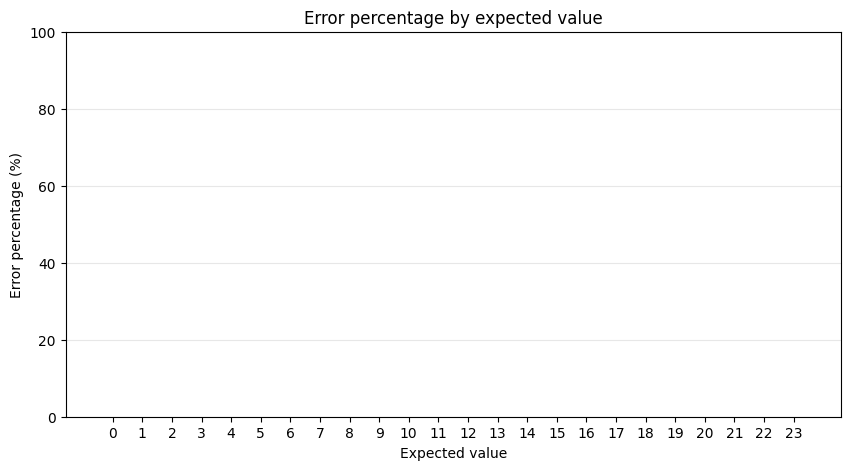

In [36]:
df = pd.read_csv('fc_0.csv')
x  = df['value'].to_numpy()
y  = op()

N    = 24
diff = (x - y) % N
dist = np.minimum(diff, N - diff)

error = dist > 0
result = (
    pd.DataFrame({
        "expected" : y,
        "actual"   : x,
        "dist"     : dist,
        "error"    : error
    })
    .groupby("expected")
    .agg(
        count = ("error", "size"),
        errors = ("error", "sum"),
        p_error = ("error", "mean")
    )
    .reset_index()
)
print(result)

result = (
    result
    .set_index("expected")
    .reindex(np.arange(24), fill_value=0)
    .reset_index()
)

result["p_error_percent"] = 100 * result["p_error"]
plt.figure(figsize=(10, 5))
plt.bar(result["expected"], result["p_error_percent"])
plt.xlabel("Expected value")
plt.ylabel("Error percentage (%)")
plt.title("Error percentage by expected value")
plt.xticks(np.arange(24))
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.show()


In [37]:
df = pd.read_csv('fc_0.csv')
x  = df['value'].to_numpy()
y  = op()
q  = np.arange(len(x))

N    = 24
diff = (x - y) % N
z = np.minimum(diff, N - diff)

# Calculate the number of values != 0
num_nonzero = np.sum(z != 0)
print(f'Number of values != 0: {num_nonzero} out of {len(z)} total values')

# Give percentage
percentage_nonzero = (num_nonzero / len(z)) * 100
print(f'Percentage of values != 0: {percentage_nonzero:.2f}%')



Number of values != 0: 0 out of 98320 total values
Percentage of values != 0: 0.00%
